# Gradient Descent from Scratch
## Finding the minimum of a function using only NumPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## The Problem
We want to find the minimum of f(x) = x²

The minimum is at x=0 where f(0)=0.

Strategy: Start anywhere, feel the slope (derivative), 
take a step downhill, repeat.

In [2]:
def f(x):
    """The function we want to minimize: f(x) = x²"""
    return x**2

def df(x):
    """Derivative of f(x) = x² is 2x
    Tells us the slope at any point x"""
    return 2*x

# Test
x_test = 3.0
print(f"At x={x_test}: f(x)={f(x_test)}, slope={df(x_test)}")

At x=3.0: f(x)=9.0, slope=6.0


## The Algorithm
Each step: x = x - learning_rate × slope

- If slope is positive (going uphill right) → move left (subtract)
- If slope is negative (going uphill left) → move right (add)
- Step size = learning_rate × slope (bigger slope = bigger step)

In [3]:
# Gradient Descent
x = 3.0          # starting point (random in real ML)
lr = 0.1         # learning rate
n_steps = 50     # number of steps

history_x = []
history_loss = []

for step in range(n_steps):
    loss = f(x)
    slope = df(x)
    
    history_x.append(x)
    history_loss.append(loss)
    
    x = x - lr * slope  # gradient descent step

print(f"Started at x=3.0, loss=9.0")
print(f"Ended at x={x:.6f}, loss={f(x):.8f}")

Started at x=3.0, loss=9.0
Ended at x=0.000043, loss=0.00000000


## Visualization
Left chart: The function with gradient descent steps shown as red dots
Right chart: Loss over time (this is what you monitor during ML training)

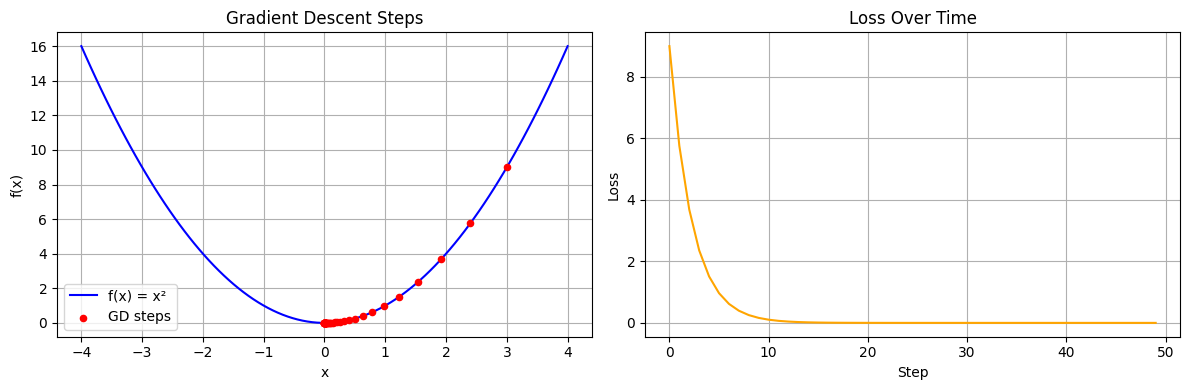

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1 — function with steps
x_range = np.linspace(-4, 4, 100)
axes[0].plot(x_range, f(x_range), label='f(x) = x²', color='blue')
axes[0].scatter(history_x, [f(x) for x in history_x], 
                color='red', s=20, zorder=5, label='GD steps')
axes[0].set_title('Gradient Descent Steps')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True)

# Chart 2 — loss curve
axes[1].plot(history_loss, color='orange')
axes[1].set_title('Loss Over Time')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Effect of Learning Rate
Too small = too slow. Too large = explodes. Just right = smooth convergence.

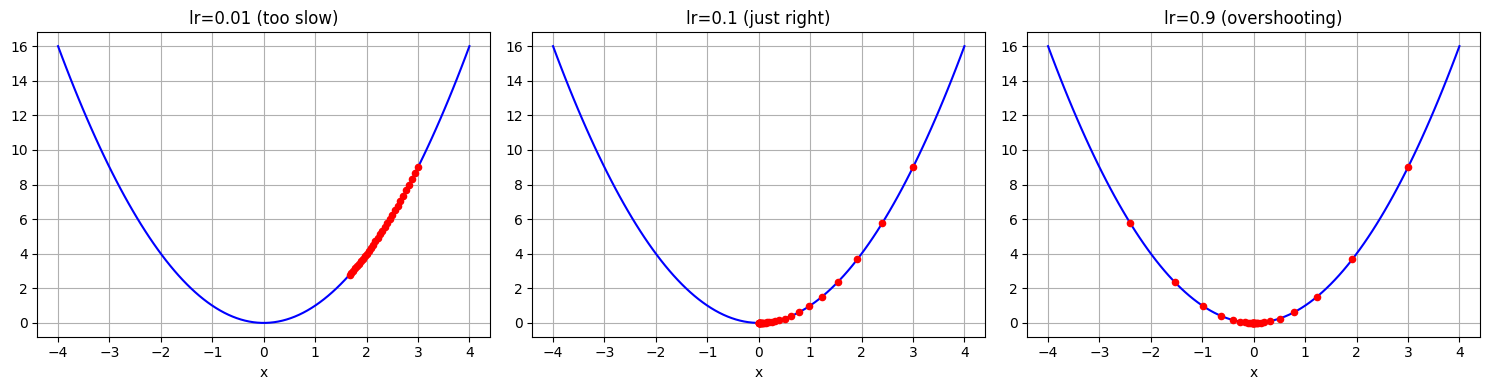

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
learning_rates = [0.01, 0.1, 0.9]
titles = ['lr=0.01 (too slow)', 'lr=0.1 (just right)', 'lr=0.9 (overshooting)']

for i, lr in enumerate(learning_rates):
    x = 3.0
    hist_x = []
    hist_loss = []
    
    for step in range(30):
        hist_x.append(x)
        hist_loss.append(f(x))
        x = x - lr * df(x)
    
    axes[i].plot(x_range, f(x_range), color='blue')
    axes[i].scatter(hist_x, [f(x) for x in hist_x], color='red', s=20, zorder=5)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('x')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## Key Takeaways

1. **Gradient descent** finds the minimum of any function by taking steps opposite to the slope
2. **Learning rate** controls step size — too small is slow, too large explodes
3. **Loss curve** going down = working correctly
4. **Derivative = 0** means we've reached the minimum
5. **This same algorithm trains every neural network** 

In [14]:
print("=== Gradient Descent Summary ===")
print(f"Starting point: x=3.0, loss=9.0")
print(f"After 50 steps: x≈0, loss≈0")
print(f"Algorithm: x = x - {0.1} × derivative(x)")
print(f"Derivative of x² = 2x")
print(f"At minimum: derivative = 0, loss = 0")

=== Gradient Descent Summary ===
Starting point: x=3.0, loss=9.0
After 50 steps: x≈0, loss≈0
Algorithm: x = x - 0.1 × derivative(x)
Derivative of x² = 2x
At minimum: derivative = 0, loss = 0
